In [1]:
%matplotlib qt
#%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})

In [2]:
import ast
import re
import numpy as np
import pandas as pd
from pathlib import Path

def _parse_w_from_csv_cell(cell):
    """
    cell looks like a string:
      "[[ 0.01]\n [-0.02]\n ...]"
    Returns np.ndarray shape (n_ch, 1) float.
    """
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return None

    # If it’s already an array-like
    if isinstance(cell, (list, tuple, np.ndarray)):
        w = np.array(cell, dtype=float)
        return w.reshape(-1, 1)

    s = str(cell).strip()

    # 1) try literal_eval on a python-style nested list
    try:
        w = np.array(ast.literal_eval(s), dtype=float)
        return w.reshape(-1, 1)
    except Exception:
        pass

    # 2) fallback: regex all numbers
    nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
    if not nums:
        return None
    w = np.array([float(x) for x in nums], dtype=float).reshape(-1, 1)
    return w

class RidgeResultLookup:
    """
    Cache the ridge CSV in memory and provide (w, lag_ms) per subject.
    Also exposes .subjects (sorted unique).
    """
    def __init__(self, csv_path):
        self.csv_path = Path(csv_path)
        df = pd.read_csv(self.csv_path)

        # robust subject parsing
        df["subject"] = df["subject"].astype(int)

        # if there are accidental duplicates, keep the last occurrence
        df = df.drop_duplicates(subset=["subject"], keep="last")

        self.df = df.set_index("subject", drop=False)

        # ✅ list of subjects coming from the file
        self.subjects = sorted(self.df.index.astype(int).tolist())

    def load_subject(self, sub, which="star"):
        sub = int(sub)
        if sub not in self.df.index:
            return None, 0

        row = self.df.loc[sub]

        if which == "star":
            w = _parse_w_from_csv_cell(row.get("w_star"))
            lag_ms = int(row.get("best_lag_ms_star", 0))
        elif which == "lam0":
            w = _parse_w_from_csv_cell(row.get("w_lam0"))
            lag_ms = int(row.get("best_lag_ms_lam0", 0))
        else:
            raise ValueError("which must be 'star' or 'lam0'")

        return w, lag_ms


In [3]:
import numpy as np

# import these from your ridge file
from ridge_regression_functions import (
    load_all_trials,
    split_trials_by_condition,
    normalise_eeg,
    WIN_OFFSET1,
    WIN_OFFSET2,
)

SAMPLE_RATE = 100.0  # 10 ms/sample → 100 Hz (this matches your pipeline) :contentReference[oaicite:5]{index=5}

def _project_and_align_ridge(eeg, pupil, w, lag_samples=0):
    """
    Match ridge_regression_functions.concat_trials() alignment convention:
      +lag => EEG delayed (drop early EEG, drop late pupil)
      -lag => EEG advanced (drop late EEG, drop early pupil)
    And do: window -> lag trim -> normalise_eeg -> projection.
    """
    if w is None:
        return np.empty(0), np.empty(0)

    # shapes
    eeg = np.asarray(eeg)
    if eeg.ndim == 1:
        eeg = eeg[:, None]  # (T, C)

    pupil = np.asarray(pupil)
    pupil_1d = pupil[:, 0] if (pupil.ndim == 2 and pupil.shape[1] == 1) else pupil.ravel()

    # common window (same idea as concat_trials)
    T0 = min(len(eeg), len(pupil_1d))
    if T0 <= 0:
        return np.empty(0), np.empty(0)

    start = WIN_OFFSET1
    stop  = T0 - WIN_OFFSET2
    if stop <= start:
        return np.empty(0), np.empty(0)

    eeg_w   = eeg[start:stop, :]
    pupil_w = pupil_1d[start:stop]
    Tw = len(pupil_w)
    if Tw <= 0:
        return np.empty(0), np.empty(0)

    # lag trim (NO roll, NO wrap)
    if abs(lag_samples) >= Tw:
        return np.empty(0), np.empty(0)

    if lag_samples >= 0:
        eeg_seg   = eeg_w[lag_samples:, :]
        pupil_seg = pupil_w[:Tw - lag_samples]
    else:
        s = -lag_samples
        eeg_seg   = eeg_w[:Tw - s, :]
        pupil_seg = pupil_w[s:]

    if len(pupil_seg) == 0:
        return np.empty(0), np.empty(0)

    # IMPORTANT: normalise EEG like ridge did before fitting w
    eeg_seg = normalise_eeg(eeg_seg)

    # weights shape checks
    w = np.asarray(w).reshape(-1, 1)  # (C,1)
    C = eeg_seg.shape[1]
    if w.shape[0] != C:
        # safest is to skip — otherwise you’re multiplying mismatched channels
        # (you can add channel-name matching here if needed)
        return np.empty(0), np.empty(0)

    eeg_roi = (eeg_seg @ w).ravel()  # (T,)

    return eeg_roi, pupil_seg


def _trialwise_z(x):
    x = np.asarray(x)
    if x.size == 0:
        return x
    mu = x.mean()
    sd = x.std(ddof=0)
    return (x - mu) / (sd if sd > 0 else 1.0)


In [4]:
def extract_trials_for_plot_ridge(
    ridge_csv_path,
    eeg_root,
    pupil_root,
    subjects=None,
    loads=(5, 9, 13),
    tasks=("memory", "control"),
    which="star",
    z_per_trial=True,
    use_lag_for_plot=True,   # ✅ new
):
    eeg_root = Path(eeg_root)
    pupil_root = Path(pupil_root)

    ridge_lookup = RidgeResultLookup(ridge_csv_path)

    if subjects is None:
        subjects = ridge_lookup.subjects
    if not subjects:
        print("No subjects found in ridge CSV.")
        return None

    panel_trials = {(cond, load): {"eeg": [], "pupil": []}
                    for cond in tasks for load in loads}

    for sub in subjects:
        print(f"Loading subject {sub}...")

        w, lag_ms = ridge_lookup.load_subject(sub, which=which)
        if w is None:
            print(f"  sub {sub}: no ridge weights ({which}); skipping.")
            continue

        # ✅ for stimulus-locked visualisation, force lag=0
        if not use_lag_for_plot:
            lag_samples = 0
        else:
            lag_samples = int(round(lag_ms / 10.0))

        try:
            trials = load_all_trials(int(sub), eeg_root, pupil_root)
        except Exception as e:
            print(f"  sub {sub}: load_all_trials failed ({e}); skipping.")
            continue

        mem, ctl = split_trials_by_condition(trials)
        by_cond = {"memory": mem, "control": ctl}

        for cond in tasks:
            for eeg, pupil, meta in by_cond[cond]:
                L = meta.get("load", None)
                if L not in loads:
                    continue

                eeg_roi, pupil_1d = _project_and_align_ridge(eeg, pupil, w, lag_samples)
                if eeg_roi.size == 0:
                    continue

                if z_per_trial:
                    eeg_roi  = _trialwise_z(eeg_roi)
                    pupil_1d = _trialwise_z(pupil_1d)

                panel_trials[(cond, L)]["eeg"].append(eeg_roi)
                panel_trials[(cond, L)]["pupil"].append(pupil_1d)

    return panel_trials


def plot_grand_average_trials(panel_trials, tasks = ["memory", "control"], loads=(5,9,13), z_per_trial=True, save_name="grand_average_trials2.png"):
# --- plot 3×2 grid ---
    colors = {5: "#1f77b4", 9: "#ff7f0e", 13: "#2ca02c"}
    fig, axes = plt.subplots(len(loads), 2, figsize=(12, 9), sharey="row")
    legend_handles, legend_labels = [], []

    for r, load in enumerate(loads):
        for c, cond in enumerate(tasks):
            ax = axes[r, c]
            eeg_list  = panel_trials[(cond, load)]["eeg"]
            pup_list  = panel_trials[(cond, load)]["pupil"]

            if not eeg_list:
                ax.set_visible(False)
                continue

            # align all trials to the shortest length for this panel
            Lmin = min(map(len, eeg_list + pup_list))
            eeg_stack = np.stack([e[:Lmin] for e in eeg_list], axis=0)  # (Ntrials, L)
            pup_stack = np.stack([p[:Lmin] for p in pup_list], axis=0)

            # grand mean ± SEM across trials
            eeg_mu  = eeg_stack.mean(0)
            eeg_sem = eeg_stack.std(0, ddof=1) / np.sqrt(eeg_stack.shape[0])

            pup_mu  = pup_stack.mean(0)
            pup_sem = pup_stack.std(0, ddof=1) / np.sqrt(pup_stack.shape[0])

            # time axis (assumes 100 Hz)
            t = np.arange(Lmin) / 100.0

            ln1, = ax.plot(t, pup_mu, color=colors[load], label="Pupil")
            ax.fill_between(t, pup_mu - pup_sem, pup_mu + pup_sem, color=colors[load], alpha=.25)

            axr = ax.twinx()
            ln2, = axr.plot(t, eeg_mu, color="black", lw=1.2, label="θ")
            axr.fill_between(t, eeg_mu - eeg_sem, eeg_mu + eeg_sem, color="black", alpha=.15)

            # ✅ use the actual time range of your data
            ax.set_xlim(t[0], 25)
            ax.set_yticks([]); axr.set_yticks([])
            ax.axvline(0, ls="--", c="k", lw=.7)

            if c == 0:
                ax.set_ylabel(f"Load {load:02d}")
            if r == 0:
                n_tr = eeg_stack.shape[0]
                ax.set_title(f"{cond.capitalize()}")

            if not legend_handles:
                legend_handles.extend([ln1, ln2])
                legend_labels.extend(["Pupil", "θ"])

    axes[0, 0].legend(legend_handles, legend_labels, loc="upper right", frameon=False)
    total_trials = sum(len(panel_trials[k]["eeg"]) for k in panel_trials)
    #fig.suptitle(f"Grand average across trials (total N={total_trials}, z_per_trial={z_per_trial})")
    fig.tight_layout(rect=[0, 0.03, 1, 0.97])
    return fig


In [6]:
RIDGE_CSV = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_5seconds_window_SLOW\dfk_ridge_UPDATE.csv"
EEG_ROOT  = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow"
PUP_ROOT  = r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow"

panel_trials = extract_trials_for_plot_ridge(
    ridge_csv_path=RIDGE_CSV,
    eeg_root=EEG_ROOT,
    pupil_root=PUP_ROOT,
    subjects=None,        # ✅ automatically from CSV
    which="star",
    loads=(5, 9, 13),
    tasks=("memory", "control"),
    z_per_trial=True,
)


Loading subject 33...
Loading subject 34...
Loading subject 36...
Loading subject 38...
Loading subject 39...
Loading subject 40...
Loading subject 41...
Loading subject 42...
Loading subject 43...
Loading subject 44...
Loading subject 45...
Loading subject 47...
Loading subject 48...
Loading subject 49...
Loading subject 50...
Loading subject 51...
Loading subject 52...
Loading subject 54...
Loading subject 55...
Loading subject 56...
Loading subject 57...
Loading subject 58...
Loading subject 59...
Loading subject 60...
Loading subject 62...
Loading subject 63...
Loading subject 64...
Loading subject 65...
Loading subject 67...
Loading subject 70...
Loading subject 71...
Loading subject 72...
Loading subject 73...
Loading subject 74...
Loading subject 75...
Loading subject 76...
Loading subject 77...
Loading subject 79...
Loading subject 80...
Loading subject 81...
Loading subject 82...
Loading subject 83...
Loading subject 85...
Loading subject 86...
Loading subject 87...
Loading su

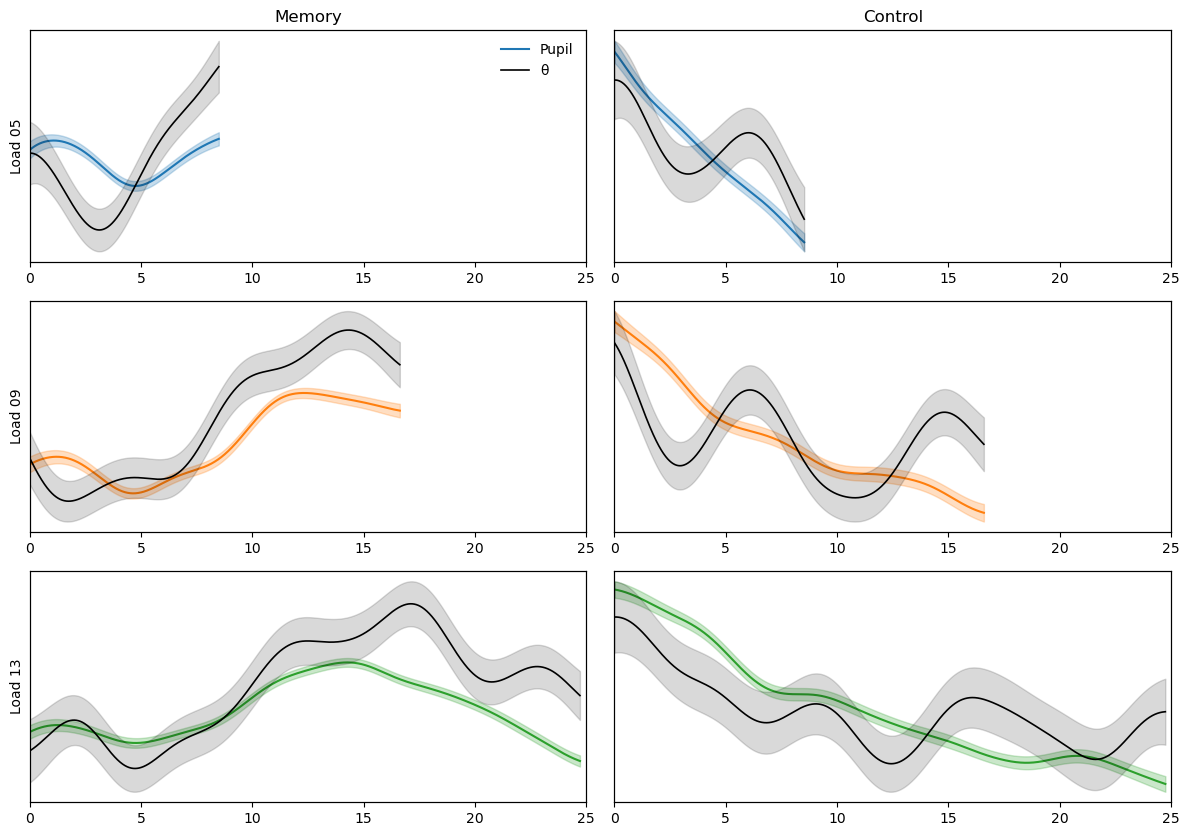

In [10]:
import matplotlib.pyplot as plt
plot_grand_average_trials(panel_trials, tasks=["memory", "control"], loads=(5, 9, 13))
plt.show()


In [15]:

panel_trials_Phasic_lock = extract_trials_for_plot_ridge(
    ridge_csv_path=COMPONENTS["Phasic"]["ridge_csv"],
    eeg_root=COMPONENTS["Phasic"]["eeg_root"],
    pupil_root=COMPONENTS["Phasic"]["pupil_root"],
    which="star",
    z_per_trial=True,
    use_lag_for_plot=False,  # ✅ stimulus-locked
)

fig = plot_grand_average_trials(panel_trials_Phasic_lock, tasks=["memory","control"], loads=(5,9,13))
fig.suptitle("Phasic (stimulus-locked: lag=0 for plotting)", y=1.02)
plt.show()


Loading subject 33...
Loading subject 34...
Loading subject 36...
Loading subject 38...
Loading subject 39...
Loading subject 40...
Loading subject 41...
Loading subject 42...
Loading subject 43...
Loading subject 44...
Loading subject 45...
Loading subject 47...
Loading subject 48...
Loading subject 49...
Loading subject 50...
Loading subject 51...
Loading subject 52...
Loading subject 54...
Loading subject 55...
Loading subject 56...
Loading subject 57...
Loading subject 58...
Loading subject 59...
Loading subject 62...
Loading subject 63...
Loading subject 64...
Loading subject 65...
Loading subject 67...
Loading subject 69...
Loading subject 70...
Loading subject 71...
Loading subject 72...
Loading subject 73...
Loading subject 74...
Loading subject 75...
Loading subject 76...
Loading subject 77...
Loading subject 79...
Loading subject 80...
Loading subject 81...
Loading subject 82...
Loading subject 83...
Loading subject 85...
Loading subject 86...
Loading subject 87...
Loading su

In [ ]:
all_panel_trials_lock["tonic"] = panel_trials_Tonic_lock

In [18]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pickle

def save_panel_trials(panel_trials, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "wb") as f:
        pickle.dump(panel_trials, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_panel_trials(path):
    with open(path, "rb") as f:
        return pickle.load(f)


# --- Define your 3 components here (EDIT PATHS if needed) ---
COMPONENTS = {
    "Combined": {
        "ridge_csv": r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_ALL\dfk_ridge_ALL.csv",
        "eeg_root":  r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed2",   # <- change if yours is different
        "pupil_root":r"C:/Users/cdd/Documents/Uni/Special_course/pupil_processed_clara",                    # <- change if yours is different
    },
    "Tonic": {
        "ridge_csv": r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_SLOW\dfk_ridge.csv",
        "eeg_root":  r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow",
        "pupil_root":r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow",
    },
    "Phasic": {
        "ridge_csv": r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1seconds_window_FAST\dfk_ridge.csv",
        "eeg_root":  r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_fast",  # <- change if needed
        "pupil_root":r"C:\Users\cdd\Documents\Uni\Special_course\pupil_fast",                    # <- change if needed
    },
}

OUT_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

all_panel_trials = {}  # ✅ keep in memory too

for comp_name, cfg in COMPONENTS.items():
    print(f"\n=== {comp_name} ===")
    use_lag_for_plot = True  # default to using best lag for plotting
    if comp_name == "Combined":
        use_lag_for_plot = False  # ✅ use actual best lag for Combined (since it’s already a mix)
    panel_trials = extract_trials_for_plot_ridge(
        ridge_csv_path=cfg["ridge_csv"],
        eeg_root=cfg["eeg_root"],
        pupil_root=cfg["pupil_root"],
        subjects=None,           # from CSV
        which="star",            # or "lam0"
        loads=(5, 9, 13),
        tasks=("memory", "control"),
        z_per_trial=True,
        use_lag_for_plot=use_lag_for_plot,  # ✅ stimulus-locked
    )

    if panel_trials is None:
        continue

    # ✅ store in memory
    all_panel_trials[comp_name] = panel_trials

    # ✅ save to disk
    pkl_path = OUT_DIR / f"panel_trials_{comp_name.lower()}.pkl"
    save_panel_trials(panel_trials, pkl_path)
    print(f"Saved panel_trials: {pkl_path}")

    fig = plot_grand_average_trials(
        panel_trials,
        tasks=["memory", "control"],
        loads=(5, 9, 13),
        z_per_trial=True,
    )
    fig.suptitle(f"{comp_name} (ridge: w*, best lag per subject)", y=1.02)

    out_path = OUT_DIR / f"grand_average_{comp_name.lower()}.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")



=== Combined ===
Loading subject 33...


KeyboardInterrupt: 

In [19]:
OUT_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\plots")

panel_trials = panel_trials_combined_lock
pkl_path = OUT_DIR / f"panel_trials_combined_lock.pkl"
save_panel_trials(panel_trials, pkl_path)

In [20]:
from pathlib import Path
import pickle

PLOTS_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\plots")

def load_panel_trials(pkl_path):
    with open(pkl_path, "rb") as f:
        return pickle.load(f)

all_panel_trials = {
    "Combined": load_panel_trials(PLOTS_DIR / "panel_trials_combined_lock.pkl"),
    "Tonic":    load_panel_trials(PLOTS_DIR / "panel_trials_tonic.pkl"),
    "Phasic":   load_panel_trials(PLOTS_DIR / "panel_trials_phasic.pkl"),
}

print({k: len(v) for k, v in all_panel_trials.items()})  # sanity check


{'Combined': 6, 'Tonic': 6, 'Phasic': 6}


In [22]:
import numpy as np
import matplotlib.pyplot as plt

def _sem(stack):
    n = stack.shape[0]
    if n <= 1:
        return np.zeros(stack.shape[1], dtype=float)
    return stack.std(axis=0, ddof=1) / np.sqrt(n)

def _zscore_mean_and_sem(mu, sem, eps=1e-12):
    """
    Z-score the mean time series over time; scale SEM accordingly.
    """
    mu = np.asarray(mu, float)
    sem = np.asarray(sem, float)
    m = mu.mean()
    s = mu.std(ddof=0)
    if s < eps:
        return mu * 0.0, sem * 0.0
    return (mu - m) / s, sem / s

def plot_component_grid_zavg(
    all_panel_trials,
    cond,
    loads=(5, 9, 13),
    components_order=("Combined", "Tonic", "Phasic"),
    fs=100.0,
    max_time=25.0,
):
    # map component names robustly
    keymap = {k.lower(): k for k in all_panel_trials.keys()}
    comps = [keymap.get(c.lower(), c) for c in components_order]
    comps = [c for c in comps if c in all_panel_trials]

    colors = {5: "#1f77b4", 9: "#ff7f0e", 13: "#2ca02c"}

    fig, axes = plt.subplots(
        len(loads), len(comps),
        figsize=(2.5 * len(comps), 2 * len(loads)),
        sharex="row",
        sharey="row",   # ✅ same y within each load row
    )
    axes = np.atleast_2d(axes)

    # column titles
    for j, comp in enumerate(comps):
        axes[0, j].set_title(comp, fontsize=12)

    legend_done = False

    for i, load in enumerate(loads):
        # common length for this row (across components)
        row_Lmins = []
        for comp in comps:
            eeg_list = all_panel_trials[comp].get((cond, load), {}).get("eeg", [])
            pup_list = all_panel_trials[comp].get((cond, load), {}).get("pupil", [])
            if eeg_list and pup_list:
                row_Lmins.append(min(map(len, eeg_list + pup_list)))
        if not row_Lmins:
            for j in range(len(comps)):
                axes[i, j].set_visible(False)
            continue

        Lrow = min(row_Lmins)
        t = np.arange(Lrow) / fs
        tmax = min(max_time, t[-1]) if t.size else max_time

        for j, comp in enumerate(comps):
            ax = axes[i, j]
            cell = all_panel_trials[comp].get((cond, load), {"eeg": [], "pupil": []})
            eeg_list = cell["eeg"]
            pup_list = cell["pupil"]

            if not eeg_list or not pup_list:
                ax.set_visible(False)
                continue

            eeg_stack = np.stack([e[:Lrow] for e in eeg_list], axis=0)
            pup_stack = np.stack([p[:Lrow] for p in pup_list], axis=0)

            eeg_mu  = eeg_stack.mean(axis=0)
            eeg_sem = _sem(eeg_stack)
            pup_mu  = pup_stack.mean(axis=0)
            pup_sem = _sem(pup_stack)

            # ✅ z-score the averages (and scale SEM) BEFORE plotting
            pup_mu_z, pup_sem_z = _zscore_mean_and_sem(pup_mu, pup_sem)
            eeg_mu_z, eeg_sem_z = _zscore_mean_and_sem(eeg_mu, eeg_sem)

            ln1, = ax.plot(t, pup_mu_z, color=colors[load], lw=1.6, label="Pupil")
            ax.fill_between(t, pup_mu_z - pup_sem_z, pup_mu_z + pup_sem_z, color=colors[load], alpha=0.25)

            ln2, = ax.plot(t, eeg_mu_z, color="black", lw=0.8, label="θ")
            ax.fill_between(t, eeg_mu_z - eeg_sem_z, eeg_mu_z + eeg_sem_z, color="black", alpha=0.12)

            ax.axvline(0, ls="--", c="k", lw=0.7)
            ax.set_xlim(0, 24)

            if j == 0:
                ax.set_ylabel(f"Seq. length {load:02d}")
            else:
                ax.set_yticks([])

            if i == len(loads) - 1:
                ax.set_xlabel("Time (s)")
                ax.tick_params(axis="x", labelbottom=True)
            else:
                ax.set_xlabel("")
                ax.tick_params(axis="x", labelbottom=False)

            if not legend_done and i == 0 and j == len(comps) - 1:
                ax.legend([ln1, ln2], [r"$\mathbf{y}^{(\ell)}$", r"$\mathbf{X}^{(\ell)}\omega_s$"], loc="upper right", frameon=False)
                legend_done = True

    #fig.suptitle(f"{cond.capitalize()} — z-scored grand-average traces", y=0.98, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig

fig_mem = plot_component_grid_zavg(all_panel_trials, cond="memory")
fig_ctl = plot_component_grid_zavg(all_panel_trials, cond="control")
plt.show()



In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_best_lag_histograms_1x3(
    csv_paths,                    # dict: {"Combined": path, "Tonic": path, "Phasic": path}
    which="star",                 # "star" or "lam0"
    bins="auto",
    show_ms=True,
    sharey=True
):
    col = "best_lag_ms_star" if which == "star" else "best_lag_ms_lam0"
    xlabel = "Best lag (ms)" if show_ms else "Best lag (s)"

    # ---- load all lags first (so we can share x-lims) ----
    data = {}
    for name, path in csv_paths.items():
        df = pd.read_csv(path)
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in {path}")
        lags_ms = pd.to_numeric(df[col], errors="coerce").dropna().to_numpy()
        x = lags_ms if show_ms else (lags_ms / 1000.0)
        x = -x #to be consistent with other studies
        data[name] = x

    # shared x-limits
    all_x = np.concatenate(list(data.values()))
    xmin, xmax = np.min(all_x), np.max(all_x)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=sharey)
    axes = np.atleast_1d(axes)


    for ax, (name, x) in zip(axes, data.items()):
        ax.hist(x, bins=bins)
        ax.axvline(0, linestyle="-", linewidth=1, color="gray")
        ax.set_title(name)
        ax.set_xlabel(xlabel)
        ax.set_xlim(xmin, xmax)
        m = np.mean(x)
        med = np.median(x)

        ax.axvline(m,  linestyle="--",  linewidth=1.5, label="Mean", color="orange")
        ax.axvline(med, linestyle=":", linewidth=1.8, label="Median", color="red")


        if name == "Phasic":   # or use an index check
            ax.legend(frameon=False, loc="upper left")


    axes[0].set_ylabel("Count")
    #fig.suptitle(f"Best lag distribution ({which})", y=1.02)
    fig.tight_layout()
    plt.show()
    return fig


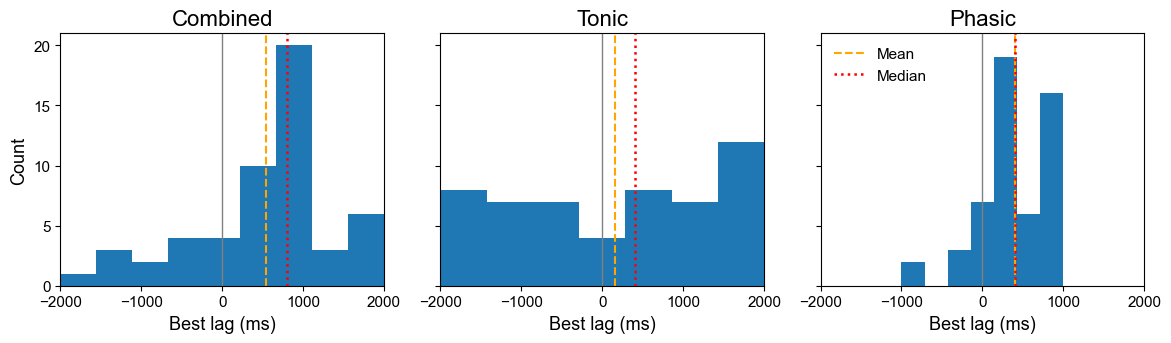

In [66]:
CSV_PATHS = {
    "Combined": r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_ALL\dfk_ridge_ALL.csv",
    "Tonic":    r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_SLOW\dfk_ridge.csv",
    "Phasic":   r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1seconds_window_FAST\dfk_ridge.csv",
}

plot_best_lag_histograms_1x3(CSV_PATHS, which="star", bins="auto", show_ms=True)


In [21]:
plot_best_lag_histogram(RIDGE_CSV, which="star", bins="auto", show_ms=True)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\cdd\\Documents\\Uni\\Special_course\\code\\Special_course\\THESIS\\ridge_reg\\dfk_ridge_UPDATE.csv'